___
**<center><font size=10>Product Review Sentiment Analysis </center></font>**
___

<center><img src="https://res.cloudinary.com/dn1j6dpd7/image/fetch/c_fill,f_auto,q_auto,w_1688/https://partners-blog-cms.livechat.com/app/uploads/2023/03/write-product-reviews.jpeg" width="720"/>
</center>


# **Overview**

This project builds a sentiment analysis system to classify product reviews as positive, neutral, or negative, using transformer-based sentence embeddings from the sentence-transformers library. It addresses the business need to interpret large volumes of unstructured customer feedback efficiently, rather than relying on manual review. The dataset includes a Product ID, the review text, and its associated sentiment label. Reviews are converted into dense semantic embeddings, which are then used to train a classification model. The goal is to help businesses spot strengths from positive feedback, clarify ambiguous signals from neutral feedback, and act quickly on issues raised in negative feedback. Ultimately, this supports smarter, data-driven decisions in product development, customer service, and brand strategy.

# **Objective**

The objective of this project is to build a sentiment classification system that accurately categorizes product reviews as positive, neutral, or negative using transformer-based sentence embeddings. This enables businesses to systematically extract insights from large volumes of unstructured customer feedback rather than relying on manual analysis. Positive reviews help highlight product strengths, neutral reviews surface ambiguous or unmet expectations, and negative reviews flag critical issues needing timely resolution. Ultimately, the model aims to support data-driven decision-making across product development, customer service, and brand communication.

## **Project Work Flow**

```
Start
  │
  ▼
Load Dataset
(Product ID, Review, Sentiment)
  │
  ▼
Preprocess & Explore Data
(Clean Text, EDA)
  │
  ▼
Generate Sentence Embeddings
(Sentence Transformer)
  │
  ▼
Train-Test Split
  │
  ▼
Train Classification Model
(Review Embeddings)
  │
  ▼
Evaluate Model
(Accuracy, F1, Confusion Matrix)
  │
  ▼
Performance Satisfactory?
 ├── Yes ──► Insights & Recommendations ──► End
 └── No ───► Tune Hyperparameters / Retrain ──► Train Classification Model
 ```

### **Data Description**

- **Product ID**: An exclusive identification number for each product

- **Product Review**: Insights and opinions shared by customers about the product

- **Sentiment**: Sentiment associated with the product review, indicating whether the review expresses a positive, negative, or neutral sentiment

## **Importing the necessary libraries**

In [ ]:
!pip install sentence-transformers

In [ ]:
import pandas as pd
import numpy as np
import warnings

from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

warnings.filterwarnings('ignore')

## **Loading the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/GenAI/product_review/Product_Reviews.csv")

## **Data Overview**

In [ ]:
data.shape

(1007, 3)

* The dataset has 1007 rows and 3 columns.

In [ ]:
data.head(5)

,Product ID,Product Review,Sentiment
0,AVpe7AsMilAPnD_xQ78G,I initially had trouble deciding between the p...,POSITIVE
1,AVpe7AsMilAPnD_xQ78G,Allow me to preface this with a little history...,POSITIVE
2,AVpe7AsMilAPnD_xQ78G,I am enjoying it so far. Great for reading. Ha...,POSITIVE
3,AVpe7AsMilAPnD_xQ78G,I bought one of the first Paperwhites and have...,POSITIVE
4,AVpe7AsMilAPnD_xQ78G,I have to say upfront - I don't like coroporat...,POSITIVE


In [ ]:
data.isnull().sum()

,0
Product ID,0
Product Review,0
Sentiment,0


* There are no missing values in the data

In [ ]:
data.duplicated().sum()

np.int64(2)

* There are 2 duplicate values in the dataset.
* We'll drop them.

In [ ]:
data = data.drop_duplicates().reset_index(drop=True)

data.duplicated().sum()

np.int64(0)

In [ ]:
data = data.reset_index(drop=True)

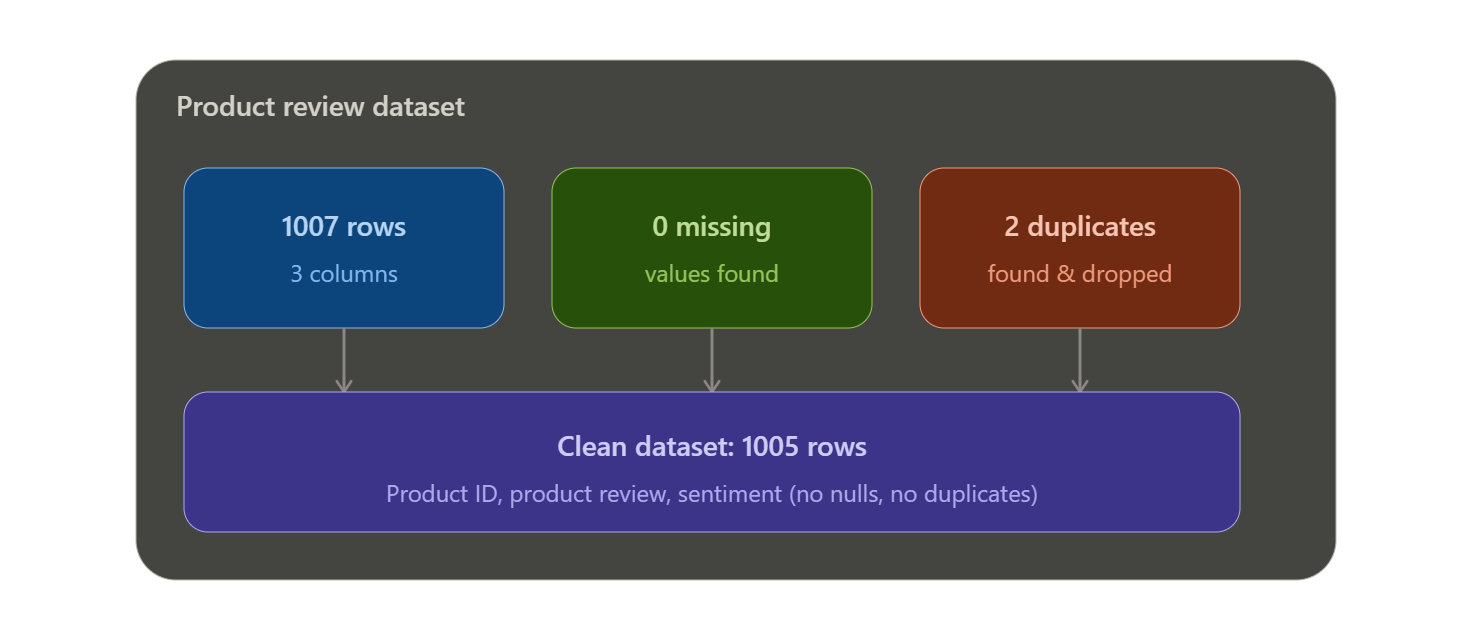

* Shape: 1007 rows × 3 columns initially, reduced to 1005 after deduplication.
* Completeness: No missing values in any column — clean dataset from that angle.
* Duplicates: 2 duplicate rows existed and were removed to avoid biasing the model.
* Structure: Product ID appears to repeat across reviews (multiple reviews per product), Product Review is free text, Sentiment is the categorical target (POSITIVE/NEUTRAL/NEGATIVE).

## **Exploratory Data Analysis (EDA)**


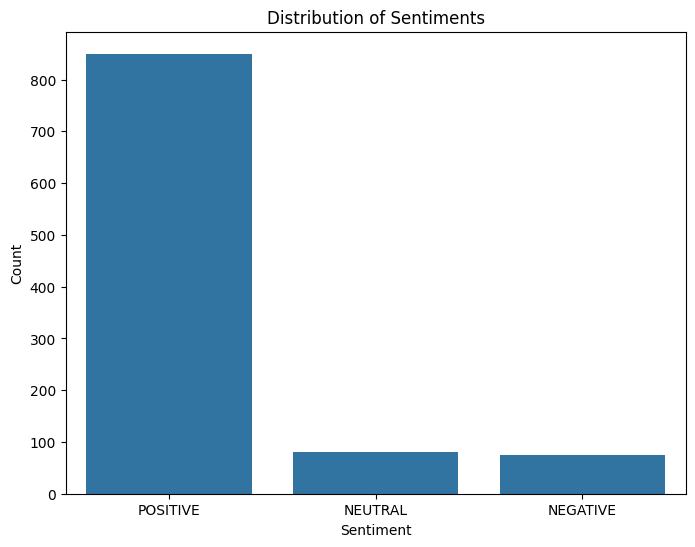

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=data)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

**Observation:**
- The dataset contains a majority of positive reviews (\~850), with neutral and negative reviews being significantly fewer, around 75 each.


## **Defining the Sentence Transformer  Model**

In [ ]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

 all-MiniLM-L6-v2 is a lightweight, widely-used sentence embedding model — it maps a sentence (of any length) to a 384-dimensional dense vector that captures its semantic meaning.

In [ ]:
print(type(data['Product Review']))

<class 'pandas.core.series.Series'>


In [ ]:
embedding_matrix = model.encode(
    data['Product Review'].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
embedding_matrix.shape

(1005, 384)

* model.encode(...) runs every one of the ~1005 cleaned reviews through this model, producing a matrix of shape (1005, 384) — one 384-dimensional embedding per review.
* These embeddings are what get used later as the input features (X) for the classifiers (Random Forest, Gradient Boosting) instead of raw text — this is the "transformer" part of the "Embeddings to Transformers" module.

## **Data Pre-processing**

### Splitting the dataset

In [ ]:
X = embedding_matrix
y = data['Sentiment']
print(X)
print("hi")
print(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

[[-0.06763466 -0.02208138  0.05924185 ... -0.06072132 -0.07869101
   0.0665011 ]
 [-0.03585525 -0.00802992  0.06164538 ... -0.0928374  -0.05767117
   0.08630549]
 [-0.03356336 -0.02274513  0.04016221 ... -0.06302886 -0.06097085
   0.0911384 ]
 ...
 [-0.02053016 -0.13517569  0.01268503 ...  0.02097021 -0.06092423
  -0.05930506]
 [-0.0511225  -0.0955516   0.02730997 ... -0.02450615 -0.0337762
   0.03903214]
 [ 0.01656119 -0.05908973  0.08064228 ...  0.02733188 -0.01889756
  -0.01989325]]
hi
0       POSITIVE
1       POSITIVE
2       POSITIVE
3       POSITIVE
4       POSITIVE
          ...   
1000     NEUTRAL
1001    NEGATIVE
1002    NEGATIVE
1003     NEUTRAL
1004    NEGATIVE
Name: Sentiment, Length: 1005, dtype: object


* X = the 384-dimensional sentence embeddings (from all-MiniLM-L6-v2)
* y = the Sentiment labels (POSITIVE / NEUTRAL / NEGATIVE), confirmed as 1005 entries (after deduplication)
* stratify=y ensures the class imbalance (mostly POSITIVE) is preserved proportionally in both train and test sets
* random_state=42 makes the split reproducible

In [ ]:
print('Shape of training data:', X_train.shape)
print('Shape of testing data:', X_test.shape)
print('Shape of training labels:', y_train.shape)
print('Shape of testing labels:', y_test.shape)
print(y_train)
print("hi")
print(y_test)

Shape of training data: (804, 384)
Shape of testing data: (201, 384)
Shape of training labels: (804,)
Shape of testing labels: (201,)
102     NEUTRAL
877    POSITIVE
490    POSITIVE
295    POSITIVE
834    POSITIVE
         ...   
436    POSITIVE
612    POSITIVE
894    POSITIVE
329     NEUTRAL
978    NEGATIVE
Name: Sentiment, Length: 804, dtype: object
hi
194    POSITIVE
596    POSITIVE
273    NEGATIVE
149    POSITIVE
775    POSITIVE
         ...   
311    POSITIVE
835    POSITIVE
178    POSITIVE
199    POSITIVE
491    POSITIVE
Name: Sentiment, Length: 201, dtype: object


<center>

| Variable  | Shape      | Meaning                                      |
|-----------|------------|----------------------------------------------|
| `X_train` | (804, 384) | 804 training reviews, each represented by a 384-dimensional sentence embedding |
| `X_test`  | (201, 384) | 201 testing reviews, each represented by a 384-dimensional sentence embedding |
| `y_train` | (804,)     | Sentiment labels corresponding to the 804 training reviews |
| `y_test`  | (201,)     | Sentiment labels corresponding to the 201 testing reviews |
</center>

## **Model Building - Transformers + ML**

### **Model Evaluation Criteria**

1. **Accuracy** is used to measure the overall correctness of the model by calculating the proportion of total correct predictions across all sentiment classes.

2. **F1 Score** is used to evaluate the balance between precision and recall, providing a more reliable performance metric, especially in the presence of class imbalance among positive, neutral, and negative sentiments.


In [ ]:
model_eval_results = pd.DataFrame(columns=['Model', 'Train_Accuracy', 'Train_F1', 'Test_Accuracy', 'Test_F1'])

### Random Forest Classifier

In [ ]:
rf_transformer = RandomForestClassifier(random_state = 42)

rf_transformer.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import f1_score

y_train_pred_rf = rf_transformer.predict(X_train)
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
train_f1_rf = f1_score(y_train, y_train_pred_rf, average='weighted')

y_test_pred_rf = rf_transformer.predict(X_test)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
test_f1_rf = f1_score(y_test, y_test_pred_rf, average='weighted')

new_row_rf = pd.DataFrame([{
    'Model': 'RandomForest + Transformer',
    'Train_Accuracy': train_accuracy_rf,
    'Train_F1': train_f1_rf,
    'Test_Accuracy': test_accuracy_rf,
    'Test_F1': test_f1_rf
}])

model_eval_results = pd.concat([model_eval_results, new_row_rf], ignore_index=True)

model_eval_results

,Model,Train_Accuracy,Train_F1,Test_Accuracy,Test_F1
0,RandomForest + Transformer,1.0,1.0,0.865672,0.818014


The RandomForest model with Transformer embeddings achieved full training accuracy and F1 score, and performed well on the test set with 86.5% accuracy and an F1 score of 81.8%, indicating good generalization.


### **Gradient Boost Classifier**


In [ ]:
gb_transformer = GradientBoostingClassifier(random_state = 42)

gb_transformer.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
y_train_pred_gb = gb_transformer.predict(X_train)
train_accuracy_gb = accuracy_score(y_train, y_train_pred_gb)
train_f1_gb = f1_score(y_train, y_train_pred_gb, average='weighted')

y_test_pred_gb = gb_transformer.predict(X_test)
test_accuracy_gb = accuracy_score(y_test, y_test_pred_gb)
test_f1_gb = f1_score(y_test, y_test_pred_gb, average='weighted')

new_row_gb = pd.DataFrame([{
    'Model': 'GradientBoost + Transformer',
    'Train_Accuracy': train_accuracy_gb,
    'Train_F1': train_f1_gb,
    'Test_Accuracy': test_accuracy_gb,
    'Test_F1': test_f1_gb
}])

model_eval_results = pd.concat([model_eval_results, new_row_gb], ignore_index=True)

model_eval_results

,Model,Train_Accuracy,Train_F1,Test_Accuracy,Test_F1
0,RandomForest + Transformer,1.000000,1.000000,0.865672,0.818014
1,GradientBoost + Transformer,0.998756,0.998752,0.840796,0.803252


The GradientBoost model with Transformer embeddings achieved good training metrics and delivered a test accuracy of 84.07% with an F1 score of 80.3%, indicating slightly lower performance compared to the Random Forest model.


# **Logistic Regression**

Logistic Regression is introduced with class_weight="balanced" to reduce the effect of the highly imbalanced sentiment classes. This allows the model to give greater importance to the minority Negative and Neutral classes.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    C=1.0,
    random_state=42
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Results")
print("=" * 50)

print(classification_report(
    y_test,
    lr_pred,
    zero_division=0
))

print("\nConfusion Matrix:")
print(
    pd.crosstab(
        y_test,
        lr_pred,
        rownames=["Actual"],
        colnames=["Predicted"]
    )
)

Logistic Regression Results
              precision    recall  f1-score   support

    NEGATIVE       0.39      0.87      0.54        15
     NEUTRAL       0.18      0.38      0.24        16
    POSITIVE       0.96      0.76      0.85       170

    accuracy                           0.74       201
   macro avg       0.51      0.67      0.54       201
weighted avg       0.85      0.74      0.78       201


Confusion Matrix:
Predicted  NEGATIVE  NEUTRAL  POSITIVE
Actual                                
NEGATIVE         13        2         0
NEUTRAL           4        6         6
POSITIVE         16       25       129


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Logistic Regression Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        lr_pred,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        lr_pred
    )
)

Logistic Regression Classification Report
              precision    recall  f1-score   support

    NEGATIVE       0.39      0.87      0.54        15
     NEUTRAL       0.18      0.38      0.24        16
    POSITIVE       0.96      0.76      0.85       170

    accuracy                           0.74       201
   macro avg       0.51      0.67      0.54       201
weighted avg       0.85      0.74      0.78       201


Confusion Matrix:
[[ 13   2   0]
 [  4   6   6]
 [ 16  25 129]]


The model is evaluated using a classification report and confusion matrix. The results show that Logistic Regression improved Negative-class detection, achieving 87% recall for Negative reviews, although Neutral classification remained challenging.

# **Linear SVM + Transformer**

A Linear Support Vector Machine is trained using the same Sentence Transformer embeddings with balanced class weights. SVM attempts to find decision boundaries that separate the three sentiment classes in the embedding space.

In [ ]:
# ==========================================
# LINEAR SVM + SENTENCE TRANSFORMER
# ==========================================

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

svm_model = LinearSVC(
    class_weight="balanced",
    C=1.0,
    random_state=42
)

svm_model.fit(
    X_train,
    y_train
)

svm_pred = svm_model.predict(X_test)

print("Linear SVM Results")
print("=" * 60)

print("Accuracy:",
      accuracy_score(y_test, svm_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        svm_pred,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    pd.crosstab(
        y_test,
        svm_pred,
        rownames=["Actual"],
        colnames=["Predicted"]
    )
)

Linear SVM Results
Accuracy: 0.8308457711442786

Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.47      0.47      0.47        15
     NEUTRAL       0.36      0.25      0.30        16
    POSITIVE       0.89      0.92      0.90       170

    accuracy                           0.83       201
   macro avg       0.57      0.54      0.56       201
weighted avg       0.82      0.83      0.82       201


Confusion Matrix:
Predicted  NEGATIVE  NEUTRAL  POSITIVE
Actual                                
NEGATIVE          7        0         8
NEUTRAL           1        4        11
POSITIVE          7        7       156


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

svm_pred = svm_model.predict(X_test)

print("LINEAR SVM RESULTS")
print("=" * 60)

print("Accuracy:",
      round(accuracy_score(y_test, svm_pred) * 100, 2), "%")

print("Macro Precision:",
      round(precision_score(
          y_test, svm_pred,
          average="macro",
          zero_division=0
      ) * 100, 2), "%")

print("Macro Recall:",
      round(recall_score(
          y_test, svm_pred,
          average="macro",
          zero_division=0
      ) * 100, 2), "%")

print("Macro F1:",
      round(f1_score(
          y_test, svm_pred,
          average="macro",
          zero_division=0
      ) * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    svm_pred,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    svm_pred
))

LINEAR SVM RESULTS
Accuracy: 83.08 %
Macro Precision: 57.39 %
Macro Recall: 54.48 %
Macro F1: 55.58 %

Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.47      0.47      0.47        15
     NEUTRAL       0.36      0.25      0.30        16
    POSITIVE       0.89      0.92      0.90       170

    accuracy                           0.83       201
   macro avg       0.57      0.54      0.56       201
weighted avg       0.82      0.83      0.82       201


Confusion Matrix:
[[  7   0   8]
 [  1   4  11]
 [  7   7 156]]


In [ ]:
model_scores = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "Logistic Regression",
        "Linear SVM"
    ],

    "Accuracy": [
        accuracy_score(y_test, rf_test_pred),
        accuracy_score(y_test, gb_test_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ],

    "Macro F1": [
        f1_score(y_test, rf_test_pred, average="macro"),
        f1_score(y_test, gb_test_pred, average="macro"),
        f1_score(y_test, lr_pred, average="macro"),
        f1_score(y_test, svm_pred, average="macro")
    ]
})

model_scores = model_scores.sort_values(
    by="Macro F1",
    ascending=False
)

print(model_scores)

                 Model  Accuracy  Macro F1
3           Linear SVM  0.830846  0.555770
2  Logistic Regression  0.736318  0.544155
1    Gradient Boosting  0.855721  0.536914
0        Random Forest  0.870647  0.520050


## **Models Comparison**

Random Forest → Gradient Boosting → Logistic Regression → Linear SVM

* Random Forest: Strong overall accuracy but heavily biased toward Positive reviews.
* Gradient Boosting: Slightly lower performance than Random Forest and also struggled with minority classes.
* Logistic Regression: Improved detection of Negative reviews but reduced overall accuracy and struggled with Neutral reviews.
* Linear SVM: Produced more sensible predictions across Positive, Negative, and Neutral unseen reviews and is currently the most promising model for balanced sentiment prediction.

# **Final Model Selection**


##**Prediction By using the Model**

In [ ]:
# ==========================================
# SVM - UNSEEN DATA
# ==========================================

new_reviews = [
    "The product is amazing and the quality is excellent.",
    "It is okay, nothing special about the product.",
    "Very poor quality. The product stopped working after two days.",
    "I really love this product and would definitely recommend it.",
    "The product is average and could be improved.",
    "Worst product I have ever purchased. Very disappointed."
]

new_embeddings = model.encode(new_reviews)

svm_predictions = svm_model.predict(
    new_embeddings
)

results = pd.DataFrame({
    "Product Review": new_reviews,
    "Predicted Sentiment": svm_predictions
})

print(results.to_string(index=False))

                                                Product Review Predicted Sentiment
          The product is amazing and the quality is excellent.            POSITIVE
                It is okay, nothing special about the product.            POSITIVE
Very poor quality. The product stopped working after two days.            NEGATIVE
 I really love this product and would definitely recommend it.            POSITIVE
                 The product is average and could be improved.             NEUTRAL
       Worst product I have ever purchased. Very disappointed.            NEGATIVE


# **Conclusion**

This project successfully developed a sentiment analysis system for product reviews using transformer-based sentence embeddings and machine learning classifiers. After evaluating Random Forest, Gradient Boosting, Logistic Regression, and Linear SVM, the **Linear SVM model** emerged as the most promising. While other models showed higher overall accuracy, the Linear SVM, with its `class_weight="balanced"` parameter, provided a more balanced performance across all sentiment classes (Positive, Neutral, Negative), demonstrating better recall and F1-score for the minority classes. This ensures that critical negative and ambiguous neutral feedback are not overlooked, enabling more nuanced and actionable insights for product development, customer service, and brand strategy.

___
<font size=6 color='blue'>Thank You !</font>
___